(antialiasing-section)=
# Antialiasing

We have seen in the previous sections that when an idealised image is represented using a raster array, lines and edges of curved and sloping surfaces appear jagged because pixels are square. We can attempt to reduce this effect by using **antialising** which is the process of smoothing lines and edges so that they appear less jagged. Antialiasing is achieved by illuminating the pixels adjacent to the idealised image using a colour intensity less than that of the colour intensity used for the rasterised image. There are several approaches used in practice and the most common of these is super sampling antialiasing.

## Super sampling antialiasing

**Super sampling antialiasing (SSAA)** uses a raster which has $\times 2$ or $\times 4$ the number of pixels in the horizontal and vertical directions as the display which is known as a **super sample**. The scene that is to be rendered is calculated using the super sample and the colours of each pixel on the display raster is then calculated by averaging the pixels of the super-sample raster that correspond to the pixel on the display raster. 

```{glue:figure} super-sample-aa-plot
:name: ssaa-figure

Super sampling antialiasing.
```

Consider the diagram in {numref}`ssaa-figure` where four pixels from a $\times 2$ super sample are combined to produce the display pixel. Averaging the colour triplets gives

\begin{align*}
    \text{display pixel colour} &= \frac{(255, 255, 255) + (0, 128, 255) + (255, 128, 128) + (0, 255, 64)}{4}\\
    &= (127, 191, 175).
\end{align*}

The affects of applying a $\times 2$ super sample antialiasing can be seen in {numref}`antialiased-circle-figure`. 

```{figure} /images/antialiasing_example.png
:width: 500px
:name: antialiased-circle-figure

Filled circle with (left) and without (right) $\times 2$ super sampling antialiasing applied.
```

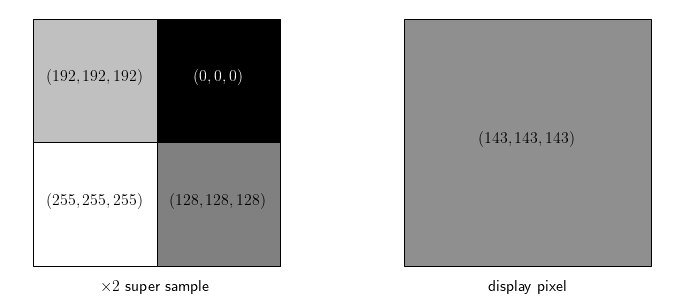

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from myst_nb import glue
plt.rcParams['text.usetex'] = True

fig, ax = plt.subplots(figsize=(12,5))

white = np.array([255, 255, 255])
blue = np.array([128, 128, 128])
red = np.array([192, 192, 192])
green = np.array([0, 0, 0])
avg = (white + blue + red + green) // 4
yellow = [1, 1, 0]

plt.fill([0, 1, 1, 0], [0, 0, 1, 1], c=white/255, ec='k')
plt.fill([1, 2, 2, 1], [0, 0, 1, 1], c=blue/255, ec='k')
plt.fill([0, 1, 1, 0], [1, 1, 2, 2], c=red/255, ec='k')
plt.fill([1, 2, 2, 1], [1, 1, 2, 2], c=green/255, ec='k')
plt.fill([3, 5, 5, 3], [0, 0, 2, 2], c=avg/255, ec='k')
plt.text(0.5, 0.5, s=f"$({white[0]}, {white[1]}, {white[2]})$", fontsize=16, ha='center')
plt.text(1.5, 0.5, s=f"$({blue[0]}, {blue[1]}, {blue[2]})$", c='k', fontsize=16, ha='center')
plt.text(0.5, 1.5, s=f"$({red[0]}, {red[1]}, {red[2]})$", c='k', fontsize=16, ha='center')
plt.text(4, 1, s=f"$({avg[0]}, {avg[1]}, {avg[2]})$", c='k', fontsize=16, ha='center')
plt.text(1.5, 1.5, s=f"$({green[0]}, {green[1]}, {green[2]})$", c='w', fontsize=16, ha='center')
plt.text(1, -0.2, s='$\\times 2$ super sample', fontsize=16, ha='center')
plt.text(4, -0.2, s='display pixel', fontsize=16, ha='center')
plt.axis('equal')
plt.axis('off')
plt.show()

glue("super-sample-aa-plot", fig, display=False)

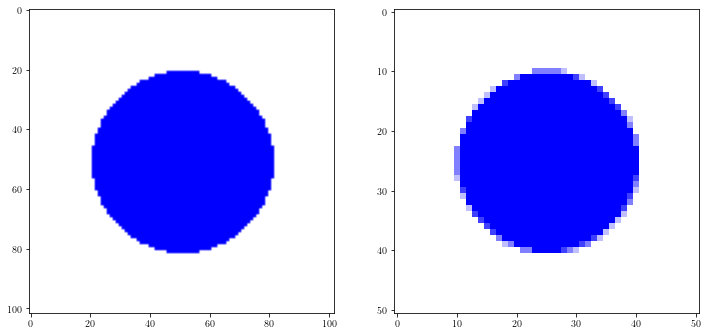

In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from myst_nb import glue
plt.rcParams['text.usetex'] = True

  
    
def drawfilledcircle(R, cx, cy, r, colour):
    
    Ny, Nx, _ = R.shape
    cx, cy, r = int(cx * Nx), int((1 - cy) * Ny), int(r * min(Nx, Ny))
    D, x, y = 5 - 4 * r, r, 0
    while y <= x:
        for i in range(3):
            R[cy + y, cx - x : cx + x + 1, i] = colour[i]
            R[cy - y, cx - x : cx + x + 1, i] = colour[i]
            R[cy + x, cx - y : cx + y + 1, i] = colour[i]
            R[cy - x, cx - y : cx + y + 1, i] = colour[i]
        
        if D > 0:
            D -= 8 * x - 8
            x -= 1
        
        D += 8 * y + 12
        y += 1
        
    return R


Nx, Ny = 51, 51
cx, cy, r = 0.5, 0.5, 0.3
colour = [0, 0, 255]

img1 = 255 * np.ones((2*Ny, 2*Nx, 3)).astype(int)
img1 = drawfilledcircle(img1, cx, cy, r, colour)

img2 = 255 * np.ones((Ny, Nx, 3)).astype(int)
for i in range(Ny):
    for j in range(Nx):
        img2[i,j,:] = (img1[2*i,2*j,:] + img1[2*i,2*j+1,:] + img1[2*i+1,2*j,:] + img1[2*i+1,2*j+1,:]) // 4   
    

fig, ax = plt.subplots(1, 2, figsize=(12, 6))
ax[0].imshow(img1)
ax[1].imshow(img2);
    
glue("ssaa-plot", fig, display=False)